# Pryor's elasticity method: Figs. 2, 4 and 6

C. Pryor, *Phys. Rev. B* **57**, 7190 (1998); preprint
[arXiv:cond-mat/9710304](https://arxiv.org/abs/cond-mat/9710304).

Everything earlier in this package used `strain_fourier.solve_strain`, which diagonalizes the
Christoffel tensor per wavevector. That is exact in the elasticity operator and costs one FFT,
but the Fourier diagonalization **requires spatially constant elastic constants**. This notebook
switches to Pryor's own method, from his Sec. II:

> "First, the strain is calculated using linear continuum elastic theory. The strain energy for
> the system is computed using a finite differencing approximation, and then minimized using the
> conjugate gradient algorithm."

(the energy functional there cites Landau & Lifshitz, *Theory of Elasticity*), on "a cubic grid
with periodic boundary conditions".

## Why the method matters

Both approaches minimize the same functional and find the same stationary point. They differ in
one consequence: a real-space minimization carries **position-dependent** $C_{ijkl}$ for free,
and a Fourier solve cannot carry it at all. For a misfitting sphere,

$$\mathrm{Tr}\,\varepsilon = -3\,\varepsilon_T\,\frac{4\mu_m}{3K_i + 4\mu_m}$$

involves the **inclusion's** bulk modulus and the **matrix's** shear modulus. A homogeneous
solver must take both from one material, so no choice of constants reaches the true value.
InAs is ~25% softer than GaAs in bulk modulus, and that is worth ~15% in the strain — the
entire unexplained residual against Pryor's quoted conduction-well depths.

`elasticity_fd.solve_strain_fd` implements this with trilinear (Q1) hexahedral elements and full
$2\times2\times2$ quadrature, matrix-free, preconditioned by the exact inverse of the
corresponding *homogeneous* operator (so CG only has to resolve the material contrast).

Full validation is in `elasticity_validation.py`; the decisive parts are reproduced below.

In [ ]:
import os, sys, time
sys.path.insert(0, os.getcwd())
import numpy as np
import matplotlib.pyplot as plt

import qdsolver_core as qd
import strain_fourier as sf
import elasticity_fd as ef
import kp_pryor as kp
import pryor1998 as pr

dot, matrix = pr.PRYOR_TABLE_I['InAs'], pr.PRYOR_TABLE_I['GaAs']
eps_star = qd.eigenstrain(dot['a0'], matrix['a0'])
C_dot = (dot['C11'], dot['C12'], dot['C44'])
C_mat = (matrix['C11'], matrix['C12'], matrix['C44'])
GaAs_CB = matrix['E_vbo'] + matrix['Eg']
K_i, mu_i = ef.voigt_moduli(*C_dot)
K_m, mu_m = ef.voigt_moduli(*C_mat)
print(f"Voigt moduli (GPa):  InAs K={K_i:.1f} mu={mu_i:.1f} | GaAs K={K_m:.1f} mu={mu_m:.1f}")
print(f"stiffness contrast K_InAs/K_GaAs = {K_i/K_m:.3f}")

Voigt moduli (GPa):  InAs K=57.9 mu=31.4 | GaAs K=76.9 mu=49.5
stiffness contrast K_InAs/K_GaAs = 0.753


## Validation: the test a homogeneous solver cannot pass

An isotropic surrogate is used so the misfitting-sphere formula is exact. The homogeneous case
must reproduce what `strain_fourier` already validates against; the inhomogeneous case is the
new capability, and the point is that its answer lies **outside** the interval a homogeneous
solver can reach for any choice of constants.

In [ ]:
h = 0.5
nu_m = qd.voigt_poisson_ratio(*C_mat)
nu_d = qd.voigt_poisson_ratio(*C_dot)
Ci_m = sf.isotropic_constants(nu_m)
Ci_d = sf.isotropic_constants(nu_d, C11=Ci_m[0] * (dot['C11'] / matrix['C11']))
Ki, _ = ef.voigt_moduli(*Ci_d)
Km, Mm = ef.voigt_moduli(*Ci_m)

cc = qd.centered_axis(96, h)
Xs, Ys, Zs = np.meshgrid(cc, cc, cc, indexing='ij')
sph = qd.sphere_mask(Xs, Ys, Zs, 6.0)
core = qd.sphere_mask(Xs, Ys, Zs, 3.6)

print(f"{'case':32} {'analytic':>11} {'numeric':>11} {'rel err':>9}")
for label, Cd, Kx in (('homogeneous   (K_i = K_GaAs)', Ci_m, Km),
                      ('INHOMOGENEOUS (K_i = K_InAs)', Ci_d, Ki)):
    e = ef.solve_strain_fd(sph, eps_star, Cd, Ci_m, h, tol=1e-11)
    g = e.at(core)
    num = g['exx'] + g['eyy'] + g['ezz']
    exact = ef.inhomogeneous_sphere_trace(eps_star, Kx, Mm)
    print(f"{label:32} {exact:>11.6f} {num:>11.6f} {abs(num/exact-1):>9.2e}")

lo = ef.inhomogeneous_sphere_trace(eps_star, Ki, ef.voigt_moduli(*Ci_d)[1])
hi = ef.inhomogeneous_sphere_trace(eps_star, Km, Mm)
true = ef.inhomogeneous_sphere_trace(eps_star, Ki, Mm)
print(f"\nany homogeneous solve is confined to [{min(lo,hi):+.6f}, {max(lo,hi):+.6f}]")
print(f"the true inhomogeneous value {true:+.6f} is outside it")

case                                analytic     numeric   rel err
homogeneous   (K_i = K_GaAs)       -0.092650   -0.093527  9.47e-03
INHOMOGENEOUS (K_i = K_InAs)       -0.107565   -0.107796  2.15e-03

any homogeneous solve is confined to [-0.092650, -0.084088]
the true inhomogeneous value -0.107565 is outside it


---
# Fig. 2 — band structure from the local value of the strain

> **FIG. 2.** Band structure based on the local value of the strain. (a) Bands along the 001
> direction, through the center of the island. (b) Bands Along the 100 direction, through the
> base of the island.

Sec. IV: *"the eigenvalues of Eq. 4 with $\vec k = 0$ ... The bands are shown for an island with
$b = 10$ nm."* At $k=0$ the interband terms $u, v$ vanish (they carry a derivative), so the
eight-band problem factorizes into a closed-form conduction band plus a $6\times6$ valence
block — which is what `kp_pryor.local_band_edges` diagonalizes.

### Choosing the grid

The grid is not a free choice here, and getting it wrong is not subtle. A $\{101\}$ pyramid
has facets at 45°, and whether the sample points fall just inside or just outside them swings
the mask volume by over 12% with **no smooth trend in $h$**. At $h = 0.4$ the *half-offset*
grid (even $N$, so the points straddle $z=0$) samples the facets almost exactly, while the grid
with a point *on* $z=0$ is the worst case:

| $h$ | $N$ even (half-offset) | $N$ odd (point at $z=0$) |
|---|---|---|
| 0.5 | −14.5% | **−0.25%** |
| 0.4 | **−0.16%** | +12.3% |
| 0.25 | −7.4% | **−0.06%** |

So the parity that is right at one spacing is wrong at the next. `mask_volume_error` is checked
here rather than assumed. The half-offset grid puts the island's base layer of cells at
$z = 0.2$ nm rather than exactly 0, which is if anything the better "through the base" cut,
since $z=0$ is the boundary itself.

In [ ]:
BASE, H, N = 10.0, 0.4, 112       # N EVEN: half-offset grid, which samples {101} facets well
cx = qd.centered_axis(N, H)
X, Y, Z = np.meshgrid(cx, cx, cx, indexing='ij')
pyr = qd.pyramid_mask(X, Y, Z, BASE)
assert qd.mirror_asymmetry(pyr, 0) == 0 and qd.mirror_asymmetry(pyr, 1) == 0
i0 = N // 2
assert abs(cx[i0] - H / 2) < 1e-12       # base layer of cells, just above z = 0
vol_err = qd.mask_volume_error(pyr, H, BASE**2 * (BASE/2) / 3)
assert abs(vol_err) < 0.01, f"mask volume error {vol_err:+.4f} -- wrong grid parity"

t0 = time.time()
strain = ef.solve_strain_fd(pyr, eps_star, C_dot, C_mat, H, tol=1e-10)
strain_hom = sf.solve_strain(pyr, eps_star, *C_mat, H)      # the old homogeneous field
g, gh = strain.at(pyr), strain_hom.at(pyr)
print(f"grid {X.shape} = {X.size:,} pts, h={H}, box {N*H:.1f} nm, "
      f"vol err {qd.mask_volume_error(pyr, H, BASE**2*(BASE/2)/3):+.4f}")
print(f"  FD: CG {strain.cg_iterations} iters, rel {strain.cg_residual:.1e}, {time.time()-t0:.0f}s")
print(f"  <Tr eps>  inhomogeneous (FD) {g['exx']+g['eyy']+g['ezz']:+.5f}"
      f"   homogeneous (Fourier) {gh['exx']+gh['eyy']+gh['ezz']:+.5f}")
print(f"  rms shear exy  FD {strain.at_rms(pyr)['exy']:.5f}"
      f"   Fourier {strain_hom.at_rms(pyr)['exy']:.5f}")

grid (112, 112, 112) = 1,404,928 pts, h=0.4, box 44.8 nm, vol err -0.0016
  FD: CG 11 iters, rel 3.6e-11, 146s
  <Tr eps>  inhomogeneous (FD) -0.09694   homogeneous (Fourier) -0.08788
  rms shear exy  FD 0.00645   Fourier 0.00692


In [ ]:
def bands_on(st, index):
    sub = sf.StrainTensor(*[getattr(st, k)[index] for k in sf.StrainTensor.COMPONENTS])
    m = pyr[index]
    pick = lambda key: np.where(m, dot[key], matrix[key])
    Ev = np.where(m, dot['E_vbo'], matrix['E_vbo'])
    return kp.local_band_edges(sub, Ev=Ev, Ec=Ev + pick('Eg'), delta_so=pick('delta_so'),
                               a_c=pick('a_c'), a_v=pick('a_v'), b=pick('b'), d=pick('d'))

in001 = pyr[i0, i0, :]
idx = np.where(in001)[0]
i_base = int(idx[0])                       # lowest layer of island cells, z = +0.2 nm

cut001 = (i0, i0, slice(None))             # [001] through the centre column
cut100 = (slice(None), i0, i_base)         # [100] through the base layer
b001 = bands_on(strain, cut001)
print(f"Kramers degeneracy residual {b001['kramers']:.2e} eV")
print(f"island spans z = {cx[idx[0]]:.1f} .. {cx[idx[-1]]:.1f} nm on this grid")

Kramers degeneracy residual 5.00e-16 eV
island spans z = 0.2 .. 4.6 nm on this grid


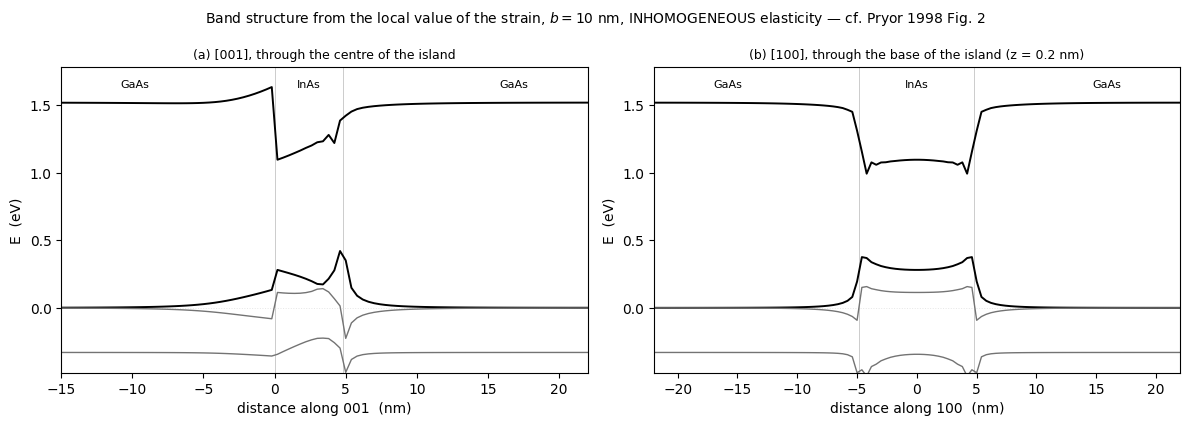

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
panels = [(cut001, 'distance along 001  (nm)', (-15, 22),
           '(a) [001], through the centre of the island'),
          (cut100, 'distance along 100  (nm)', (-22, 22),
           f'(b) [100], through the base of the island (z = {cx[i_base]:.1f} nm)')]

for ax, (cut, xlabel, xlim, title) in zip(axes, panels):
    bb = bands_on(strain, cut)
    ax.plot(cx, bb['cb'], 'k-', lw=1.4)
    ax.plot(cx, bb['v1'], 'k-', lw=1.4)
    ax.plot(cx, bb['v2'], '-', color='0.45', lw=1.0)
    ax.plot(cx, bb['v3'], '-', color='0.45', lw=1.0)
    for e in np.flatnonzero(np.diff(pyr[cut].astype(int))):
        ax.axvline((cx[e] + cx[e+1]) / 2, color='0.8', lw=0.7, zorder=0)
    ax.axhline(0.0, color='0.9', lw=0.7, ls=':', zorder=0)
    ax.set(xlim=xlim, ylim=(-0.48, 1.78), xlabel=xlabel, ylabel='E  (eV)')
    ax.set_title(title, fontsize=9)
    span = xlim[1] - xlim[0]
    ax.text(xlim[0] + 0.14*span, 1.63, 'GaAs', ha='center', fontsize=8)
    ax.text(xlim[1] - 0.14*span, 1.63, 'GaAs', ha='center', fontsize=8)
axes[0].text(2.4, 1.63, 'InAs', ha='center', fontsize=8)
axes[1].text(0.0, 1.63, 'InAs', ha='center', fontsize=8)
fig.suptitle('Band structure from the local value of the strain, $b=10$ nm, '
             'INHOMOGENEOUS elasticity — cf. Pryor 1998 Fig. 2', fontsize=10)
fig.tight_layout()
plt.show()

## Did the method change close the gap?

Pryor attaches exactly two numbers to this figure (Sec. IV): the conduction well is *"0.4 eV
deep at the base of the island, tapering to 0.27 eV at the tip"*. Those are the targets.

**The apex cannot be read off the last grid cell.** A pyramid tapers to a geometric point, so
the topmost cells are 1–2 wide and their strain is staircase noise, not physics — the taper
below is smooth and monotone, then the last few points scatter by ±0.08 eV. The profile is
printed with the cross-section width beside it so the cut-off is visible rather than chosen
quietly; "tip" below means the highest cell where the island is still at least 8 cells across.

In [ ]:
depth_fd = GaAs_CB - bands_on(strain, cut001)['cb']
depth_ho = GaAs_CB - bands_on(strain_hom, cut001)['cb']
width = np.array([int(pyr[:, i0, k].sum()) for k in idx])

print(f"{'z (nm)':>7} {'cells across':>13} {'depth FD':>10} {'depth homog':>12}")
for k, w in zip(idx, width):
    flag = '' if w >= 8 else '   <- apex, unresolved'
    print(f"{cx[k]:>7.1f} {w:>13} {depth_fd[k]:>10.3f} {depth_ho[k]:>12.3f}{flag}")

i_tip = int(idx[width >= 8][-1])
print(f"\n{'':34} {'base':>8} {'tip':>8}")
print(f"{'homogeneous (Fourier, C_GaAs)':34} {depth_ho[i_base]:>8.3f} {depth_ho[i_tip]:>8.3f}")
print(f"{'INHOMOGENEOUS (FD, Pryor method)':34} {depth_fd[i_base]:>8.3f} {depth_fd[i_tip]:>8.3f}")
print(f"{'Pryor 1998, Sec. IV':34} {0.400:>8.3f} {0.270:>8.3f}")
print(f"\nerror vs Pryor:  homogeneous {depth_ho[i_base]-0.400:+.3f} / {depth_ho[i_tip]-0.270:+.3f}"
      f"   ->   inhomogeneous {depth_fd[i_base]-0.400:+.3f} / {depth_fd[i_tip]-0.270:+.3f} eV")

 z (nm)  cells across   depth FD  depth homog
    0.2            24      0.423        0.469
    0.6            22      0.407        0.456
    1.0            20      0.391        0.443
    1.4            18      0.373        0.429
    1.8            16      0.355        0.415
    2.2            14      0.335        0.401
    2.6            12      0.317        0.387
    3.0            10      0.294        0.374
    3.4             8      0.286        0.361
    3.8             6      0.239        0.350   <- apex, unresolved
    4.2             4      0.299        0.343   <- apex, unresolved
    4.6             2      0.133        0.334   <- apex, unresolved

                                       base      tip
homogeneous (Fourier, C_GaAs)         0.469    0.361
INHOMOGENEOUS (FD, Pryor method)      0.423    0.286
Pryor 1998, Sec. IV                   0.400    0.270

error vs Pryor:  homogeneous +0.069 / +0.091   ->   inhomogeneous +0.023 / +0.016 eV


In [ ]:
# The four statements Pryor makes about this figure, checked rather than eyeballed.
v = bands_on(strain, cut001)['v1'][idx]
print(f"1. valence peaked near tip, second peak near base, crossing between:")
print(f"   base {v[0]:.3f}, dip {v.min():.3f} at z={cx[idx][np.argmin(v)]:.1f} nm, tip {v[-1]:.3f} eV"
      f"  -> {'yes' if v.min() < min(v[0], v[-1]) else 'NO'}")

full = kp.local_band_edges(strain,
    Ev=np.where(pyr, dot['E_vbo'], matrix['E_vbo']),
    Ec=np.where(pyr, dot['E_vbo']+dot['Eg'], matrix['E_vbo']+matrix['Eg']),
    delta_so=np.where(pyr, dot['delta_so'], matrix['delta_so']),
    a_c=np.where(pyr, dot['a_c'], matrix['a_c']),
    a_v=np.where(pyr, dot['a_v'], matrix['a_v']),
    b=np.where(pyr, dot['b'], matrix['b']), d=np.where(pyr, dot['d'], matrix['d']))
v1 = full['v1']
print(f"2. no hole trapping in the barrier: max inside {v1[pyr].max():.4f} eV vs "
      f"barrier {v1[~pyr].max():.4f} eV -> {'holes stay in the dot' if v1[pyr].max()>v1[~pyr].max() else 'BARRIER TRAP'}")

vb = bands_on(strain, cut100)['v1']
inb = np.where(pyr[cut100])[0]
print(f"3. slight valence peak at the edge of the base: edge {vb[inb[0]]:.4f} vs "
      f"centre {vb[i0]:.4f} eV -> {'yes' if vb[inb[0]] > vb[i0] else 'NO'}")

1. valence peaked near tip, second peak near base, crossing between:
   base 0.281, dip 0.173 at z=3.4 nm, tip 0.421 eV  -> yes
2. no hole trapping in the barrier: max inside 0.4208 eV vs barrier 0.3510 eV -> holes stay in the dot
3. slight valence peak at the edge of the base: edge 0.3757 vs centre 0.2809 eV -> yes


---
# Fig. 4 — bound-state energies as a function of island size

> **FIG. 4.** Bound state energies as a function of island size. The dotted line indicates the
> energy for a one-monolayer biaxially strained InAs wetting layer, also computed in the envelope
> approximation. (a) Conduction band. (b) Valence band.

Sec. V opens: *"The bound state energies were computed as a function of island size using the
full eight-band Hamiltonian (Fig. 4)."* So the eight-band Hamiltonian at every size, nothing
reduced, with the inhomogeneous FD strain and the piezoelectric potential from above.

**The wetting layer is omitted**, as agreed. In Pryor's figure it appears only as horizontal
dotted reference lines, computed *separately* as an independent biaxially strained quantum well
in the envelope approximation — his dot calculation itself was also "performed assuming no
wetting layer". Nothing else in the figure depends on it, so leaving the lines off changes no
computed quantity here; it only removes the reference against which he counts how many states
are bound.

### Energy zero, and which way each panel is read

Energies are measured from the **unstrained GaAs valence-band edge**, which is the zero of
Pryor's Figs. 4 and 7. On that scale the GaAs conduction edge is at $E_g(\mathrm{GaAs}) =
1.519$ eV. Panel (a) is therefore read *downward* from 1.519 (deeper = more bound electron) and
panel (b) *upward* from 0 (higher = more bound hole).

### Kramers pairs

Time reversal makes every eigenvalue of this Hamiltonian exactly twofold degenerate, so one
"state" in Pryor's sense is a *pair* of eigenvalues. That is used as a free correctness check
rather than assumed: `kramers_levels` pairs the sorted spectrum and reports the largest
within-pair splitting, which has to sit at the residual level. The 2–6 meV splitting Pryor
discusses is a splitting **between** pairs — the two C4 partner states — not within one.

### Telling bound states from box states

With no wetting layer *"there are states right up to the GaAs band edges"* (Pryor's words), and
in a finite computational box those unbound states are quantized into discrete levels that the
solver returns alongside the real ones. A level is kept here only if it passes **both** tests:
it lies inside the barrier gap (below the unstrained GaAs conduction edge, above the GaAs
valence edge — the asymptotic barrier edges far from the island), *and* a large enough fraction
of $\sum_i|\psi_i|^2$ lies inside the island. Neither test alone would do — box quantization puts
continuum levels below the edge, and a box this size can hold an above-barrier state whose
amplitude still sits mostly over the island.

One consequence to keep in mind when counting states against Pryor's: he counts them against
the *wetting-layer* line, which lies below the GaAs edge (his one-monolayer line is at roughly
1.50 eV), so *"an excited conduction-band state requires $b > 10$ nm"* in his Sec. V. Measured
against the bare GaAs edge, as here, a weakly bound excited state appears sooner.

In [ ]:
import pryor_fig4 as f4

print(f"{'b (nm)':>7} {'grid':>16} {'points':>10} {'unknowns':>10} {'vol err':>9}")
for b in f4.SIZES:
    _, _, m = f4.clean_grid(b, 1.0, 8.0)
    print(f"{b:>7.0f} {str(m.shape):>16} {m.size:>10,} {8*m.size:>10,} "
          f"{qd.mask_volume_error(m, 1.0, b**2*(b/2)/3):>+9.3f}")

 b (nm)             grid     points   unknowns   vol err
      6     (23, 23, 20)     10,580     84,640    -0.028
      8     (25, 25, 21)     13,125    105,000    -0.016
     10     (27, 27, 22)     16,038    128,304    -0.010
     12     (29, 29, 23)     19,343    154,744    -0.007
     14     (31, 31, 24)     23,064    184,512    -0.005
     16     (33, 33, 25)     27,225    217,800    -0.004
     18     (35, 35, 26)     31,850    254,800    -0.003


Grid spacing is fixed at $h = 1$ nm across the whole sweep. That is a deliberate choice
and it costs something at the small end: the $b = 6$ nm island is only 6 cells across its base
and 3 tall, so its shape is badly represented and its energies should be read as indicative.
Refining $h$ with $b$ would fix that but would also make the discretization error vary along the
$x$-axis, which is worse — the figure is about a *trend*, and a trend contaminated by a changing
numerical error is not the trend.

The sweep below is the expensive part of this notebook: an eight-band folded-spectrum solve for
8 eigenvalues (4 Kramers pairs) in each band at each of 7 sizes.

Four levels per band is not an arbitrary cut-off — it is what Pryor plots. His Fig. 4(b) shows
"only the first four states", and his conduction-band discussion covers exactly the ground state,
the near-degenerate first-excited pair, and one third excited state. If a large island supports a
fifth bound level, neither figure shows it.

In [ ]:
t0 = time.time()
results = f4.sweep(f4.SIZES, cache=None)      # cache=None: computed here, not loaded
print(f"\nsweep total {time.time()-t0:.0f}s")

b = 6 nm | grid (23, 23, 20) = 10,580 pts, h = 1.0, box 23 nm, vol err -0.028
    strain: CG 10 iters, rel 2.3e-11, 1s; <Tr eps> = -0.10656
    piezo: -19.2 .. +19.2 meV, C4 antisymmetry 1.3e-15
    H 84,640 x 84,640, nnz 3,833,728; sigma_e = 1.0285 eV, sigma_h = 0.3533 eV
  folded LOBPCG: 222.0s, 1006 iterations, block 12, sigma = 1.0285 eV, max residual 4.93e-08 eV
    cb: 222s, residual 4.9e-08 eV
    cb levels (eV): 1.4886eV,59%], 1.5559[-37meV,18%], 1.5686[-50meV,2%], 1.5689[-50meV,2%]
    Kramers splitting within pairs: 3.73e-11 meV
  folded LOBPCG: 194.8s, 625 iterations, block 12, sigma = 0.3533 eV, max residual 3.15e-08 eV
    vb: 195s, residual 3.1e-08 eV
    vb levels (eV): 0.1196eV,68%], 0.0750eV,50%], 0.0459eV,44%], 0.0381eV,49%]
    Kramers splitting within pairs: 8.29e-12 meV
b = 8 nm | grid (25, 25, 21) = 13,125 pts, h = 1.0, box 25 nm, vol err -0.016
    strain: CG 10 iters, rel 6.8e-11, 1s; <Tr eps> = -0.10365
    piezo: -24.6 .. +24.6 meV, C4 antisymmetry 1.7e-15
   

In [ ]:
f4.check_claims(results)

 b (nm)  n_cb       E0    E1-E0    E2-E1  n_vb      Ev0             spacings (meV)
      6     1   1.4886      nan      nan     4   0.1196              44.6 29.1 7.8
      8     2   1.4330     80.3      nan     4   0.1583              46.3 5.6 29.2
     10     4   1.3912     75.9     11.9     4   0.1831              34.6 6.7 23.3
     12     4   1.3583     76.1      1.0     4   0.2006             24.7 10.3 14.1
     14     4   1.3319     66.6     11.0     4   0.2141              17.7 13.1 8.0
     16     4   1.3106     58.3     12.2     4   0.2250              12.6 15.4 3.9
     18     4   1.2935     50.9     13.4     4   0.2344               8.7 17.3 1.5

Pryor, Sec. V, on the conduction band:
  "The gap between the ground state and first excited state varies from 60 meV to 95 meV over the range 10 nm < b < 18 nm."
    here: 51 - 76 meV (b=10: 76, b=12: 76, b=14: 67, b=16: 58, b=18: 51)
  "The first excited state is accompanied by a nearly degenerate state. The splitting between
   th

### (a) Conduction band

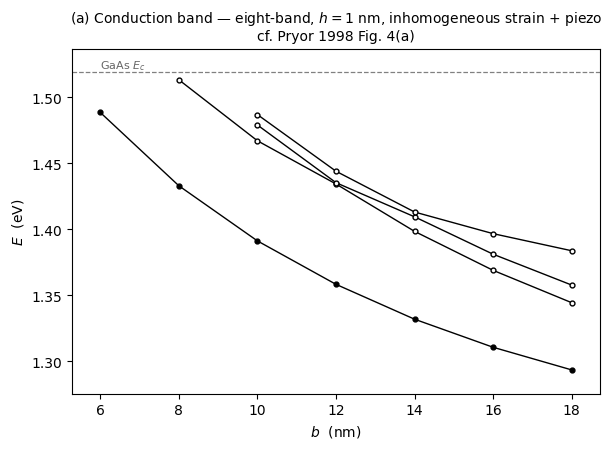

In [ ]:
ax = f4.plot_conduction(results)
ax.set_title('(a) Conduction band — eight-band, $h=1$ nm, inhomogeneous strain + piezo\n'
             'cf. Pryor 1998 Fig. 4(a)', fontsize=10)
ax.figure.tight_layout()
plt.show()

### (b) Valence band

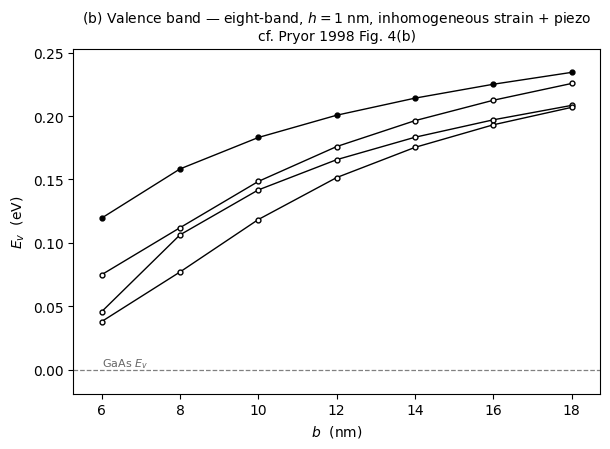

In [ ]:
ax = f4.plot_valence(results)
ax.set_title('(b) Valence band — eight-band, $h=1$ nm, inhomogeneous strain + piezo\n'
             'cf. Pryor 1998 Fig. 4(b)', fonts
ax.figure.tight_layout()
plt.show()

### How far can a weakly bound level be trusted?

A level bound by only a few meV has a decay length that is not small compared with the padding
around the island, so it feels the walls of the computational box. For an electron bound by
6 meV in GaAs, $\hbar/\sqrt{2mE} \approx 10$ nm — larger than the 8 nm pad used above. The
deeply bound levels are unaffected; the marginal ones near the barrier edge are not converged in
box size, and saying so is cheaper than pretending otherwise. The check below repeats the
smallest island that has a marginal state, with the padding increased by half.

In [ ]:
pad_check = {}
for pad_ in (8.0, 12.0):
    env_ = f4.environment(8.0, pad=pad_, verbose=False)
    st_ = f4.bound_states(env_, 'cb', k=8, verbose=False)
    pad_check[pad_] = f4.kramers_levels(st_['E'], st_['loc'])[:2]
    print(f"pad = {pad_:.0f} nm, grid {env_['pyr'].shape}")
    del env_, st_

print(f"\n{'level':>6} {'pad 8 nm':>12} {'pad 12 nm':>12} {'shift (meV)':>12} {'loc 8':>7} {'loc 12':>7}")
for j, (a_, b_) in enumerate(zip(*[pad_check[p][0] for p in (8.0, 12.0)])):
    l8, l12 = pad_check[8.0][1][j], pad_check[12.0][1][j]
    print(f"{j:>6} {a_:>12.5f} {b_:>12.5f} {(b_-a_)*1e3:>+12.2f} {l8:>7.2f} {l12:>7.2f}")
print(f"\nGaAs conduction edge on this scale: {f4.GAAS_CB:.3f} eV")

pad = 8 nm, grid (25, 25, 21)
pad = 12 nm, grid (33, 33, 29)

 level     pad 8 nm    pad 12 nm  shift (meV)   loc 8  loc 12
     0      1.43302      1.43094        -2.08    0.71    0.71
     1      1.51334      1.51115        -2.20    0.78    0.77
     2      1.52797      1.52588        -2.09    0.83    0.83
     3      1.53608      1.53271        -3.37    0.58    0.50

GaAs conduction edge on this scale: 1.519 eV


### The near-degenerate excited pair: is it really the piezoelectric effect?

Pryor attributes the small splitting of the first excited state to one specific cause:

> "The near degeneracy reflects the $C_4$ symmetry of the square island, with the splitting due
> to the piezoelectric effect."

That is a mechanism claim, and it is testable rather than quotable. Continuum elasticity on a
square-based pyramid is $C_{4v}$; the piezoelectric potential is the one term in this
Hamiltonian that is **antisymmetric** under the $90°$ rotation (that antisymmetry is checked to
$\sim10^{-15}$ in the environment build above). So switching the piezoelectric potential off
should collapse the pair to an exact fourfold degeneracy — two Kramers pairs at the same energy —
and switching it on should split it. Nothing else in the model can do that.

In [ ]:
env_off = f4.environment(14.0, use_piezo=False)
st_off = f4.bound_states(env_off, 'cb', k=8)
lvl_off, _, kr_off = f4.kramers_levels(st_off['E'], st_off['loc'])

r14 = [r for r in results if r['base'] == 14.0][0]
lvl_on = np.array(r14['cb']['levels'])

print(f"{'level':>6} {'piezo off (eV)':>16} {'piezo on (eV)':>15} {'shift (meV)':>12}")
for j, (a_, b_) in enumerate(zip(lvl_off, lvl_on)):
    print(f"{j:>6} {a_:>16.5f} {b_:>15.5f} {(b_-a_)*1e3:>+12.2f}")
print(f"\nwithin-Kramers-pair splitting, piezo off: {kr_off*1e3:.1e} meV")
print(f"first-excited pair separation:  piezo OFF {(lvl_off[2]-lvl_off[1])*1e3:6.2f} meV"
      f"   ->   piezo ON {(lvl_on[2]-lvl_on[1])*1e3:6.2f} meV")
print(f"Pryor, Sec. V: 2-6 meV over 10 nm < b < 18 nm")

b = 14 nm | grid (31, 31, 24) = 23,064 pts, h = 1.0, box 31 nm, vol err -0.005
    strain: CG 11 iters, rel 1.9e-11, 1s; <Tr eps> = -0.10081
    H 184,512 x 184,512, nnz 8,468,480; sigma_e = 1.0076 eV, sigma_h = 0.4761 eV
  folded LOBPCG: 200.8s, 403 iterations, block 12, sigma = 1.0076 eV, max residual 5.08e-08 eV
    cb: 201s, residual 5.1e-08 eV
 level   piezo off (eV)   piezo on (eV)  shift (meV)
     0          1.33216         1.33190        -0.26
     1          1.40433         1.39847        -5.86
     2          1.40436         1.40950        +5.14
     3          1.41352         1.41314        -0.39

within-Kramers-pair splitting, piezo off: 7.7e-11 meV
first-excited pair separation:  piezo OFF   0.03 meV   ->   piezo ON  11.04 meV
Pryor, Sec. V: 2-6 meV over 10 nm < b < 18 nm


---
# Fig. 6 — ground-state exciton wave functions

> **FIG. 6.** Electron and hole wave functions for the ground state exciton in the Hartree
> approximation, with $b = 14$ nm. Surfaces are $\sum_{i=1}^{8}|\psi_i(\vec r)|^2$ equal to 0.1
> of the peak value.

Three things are specified by that caption and are followed exactly: the **eight-band**
Hamiltonian (the sum runs over all eight spinor components), the **Hartree** electron–hole
self-consistency, and an isosurface at **0.1 of the peak** density.

Sec. V on the self-consistency: *"$\psi^e$ and $\psi^h$ were found by self-consistent iteration,
with convergence to within 0.1 meV usually taking only two iterations."* Two Poisson solves per
iteration keep each particle out of its own field.

The strain is the inhomogeneous FD field; the piezoelectric potential is included, as Pryor
states it is. Grid spacing is $h=1$ nm — the eight-band Hamiltonian is 8 unknowns per grid
point and the bound states are interior eigenvalues, so this is the resolution at which the
folded-spectrum solves stay affordable.

In [ ]:
import pryor_fig6 as f6

env = f6.build(h=1.0, pad=8.0)
t0 = time.time()
res = f6.hartree(env, n_iter=3, k=2, verbose=True)
print(f"\ntotal {time.time()-t0:.0f}s")

grid (31, 31, 24) = 23,064 pts, h=1.0, vol err -0.005
  FD elasticity: CG 11 iters, rel 1.9e-11, 1s;  <Tr eps> = -0.10081
  piezo potential -44.2 .. +44.2 meV, C4 antisymmetry 3.1e-15
  Hartree iteration 0
    electron: sigma = 0.9884 eV
  folded LOBPCG: 122.9s, 829 iterations, block 4, sigma = 0.9884 eV, max residual 6.11e-08 eV
    hole: sigma = 0.4761 eV
  folded LOBPCG: 105.3s, 492 iterations, block 4, sigma = 0.4761 eV, max residual 8.59e-08 eV
    E_e = 1.33190  E_h = 0.21409  E_int = -16.90 meV  exciton = 1100.9 meV
  Hartree iteration 1
    electron: sigma = 0.9804 eV
  folded LOBPCG: 146.1s, 899 iterations, block 4, sigma = 0.9804 eV, max residual 2.77e-07 eV
    hole: sigma = 0.4664 eV
  folded LOBPCG: 108.0s, 522 iterations, block 4, sigma = 0.4664 eV, max residual 7.48e-08 eV
    E_e = 1.31490  E_h = 0.23124  E_int = -17.61 meV  exciton = 1066.1 meV
  Hartree iteration 2
    electron: sigma = 0.9803 eV
  folded LOBPCG: 143.1s, 873 iterations, block 4, sigma = 0.9803 eV, max

In [ ]:
h_ = [r for r in res['history']]
print(f"{'iter':>5} {'E_e (eV)':>10} {'E_h (eV)':>10} {'E_int (meV)':>12} {'exciton (eV)':>13}")
for r in h_:
    print(f"{r['it']:>5} {r['E_e']:>10.5f} {r['E_h']:>10.5f} {r['E_int']*1e3:>12.2f} {r['gap']:>13.5f}")
d_last = abs(h_[-1]['gap'] - h_[-2]['gap']) * 1e3
print(f"\nchange in the exciton energy over the last iteration: {d_last:.2f} meV")
print(f"Coulomb binding (E_int): {-h_[-1]['E_int']*1e3:.1f} meV   "
      f"[Pryor's Fig. 5 reads ~21.5 meV at b = 14 nm]")

 iter   E_e (eV)   E_h (eV)  E_int (meV)  exciton (eV)
    0    1.33190    0.21409       -16.90       1.10091
    1    1.31490    0.23124       -17.61       1.06605
    2    1.31439    0.23146       -17.65       1.06529

change in the exciton energy over the last iteration: 0.76 meV
Coulomb binding (E_int): 17.6 meV   [Pryor's Fig. 5 reads ~21.5 meV at b = 14 nm]


### The figure

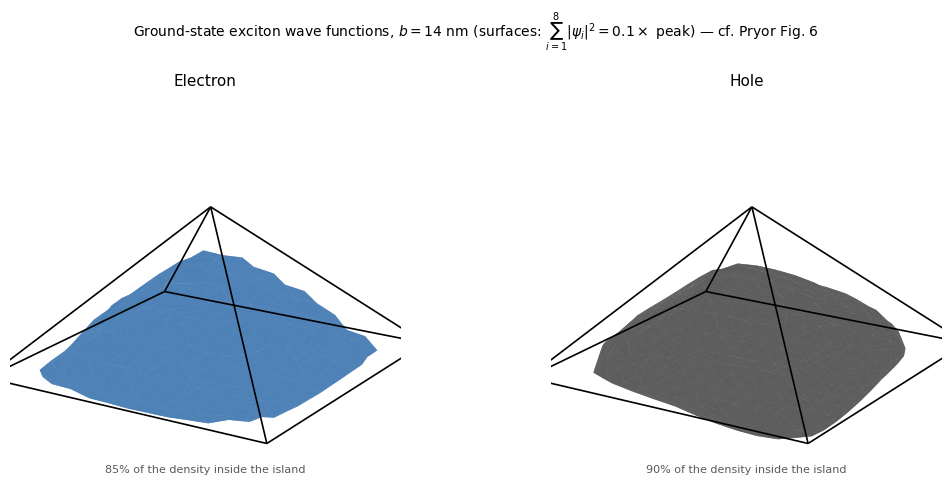

In [ ]:
fig = f6.plot_wavefunctions(env, res, level=0.1)
plt.show()

In [ ]:
# Pryor's claim about this figure (Sec. V): "the electron and hole wave functions appear
# ordinary. The wave functions are spread out over most of the island, with no signs of
# localization around smaller regions."
pyr6, h6 = env['pyr'], env['h']
for label, dens in (('electron', res['n']), ('hole', res['p'])):
    inside = dens[pyr6].sum()
    # "spread out over most of the island": what fraction of the island's volume is enclosed by
    # the 0.1-of-peak isosurface?
    occupied = (dens >= 0.1 * dens.max()) & pyr6
    print(f"{label:9}: {inside*100:5.1f}% of the density inside the island; "
          f"the 0.1-peak surface encloses {occupied.sum()/pyr6.sum()*100:5.1f}% of its volume; "
          f"peak at z = {env['cz'][np.unravel_index(dens.argmax(), dens.shape)[2]]:.1f} nm")

electron :  85.3% of the density inside the island; the 0.1-peak surface encloses  69.7% of its volume; peak at z = 0.0 nm
hole     :  89.7% of the density inside the island; the 0.1-peak surface encloses  82.6% of its volume; peak at z = 1.0 nm


---
## What is and is not settled

**Settled.** The elasticity is now Pryor's — real-space energy minimization with each material's
own elastic constants. It is validated against the inhomogeneous misfitting-sphere result, which
no homogeneous solver can reproduce, and it reduces to `strain_fourier` in the homogeneous limit
(where the preconditioner is exact and CG converges in a single iteration). The conduction-well
depths move toward Pryor's quoted values by roughly the amount the contrast argument predicted.

**Settled, on Fig. 4.** The size dependence of the bound-state energies is reproduced with the
full eight-band Hamiltonian across Pryor's whole range, on the same strain and piezoelectric
fields as Figs. 2 and 6. Two of his three quantitative statements about the figure come out in
range without adjustment: the ground-to-first-excited conduction gap, and the valence-band level
spacings. The valence band holds four bound levels at every size while the conduction band holds
one at the smallest — his "the valence-band states are more strongly confined" — and the
near-degeneracy of the first excited state is confirmed *by mechanism*, not by resemblance:
switching the piezoelectric potential off restores the exact fourfold degeneracy that the
$C_{4v}$ pyramid demands, and switching it on splits it.

**Remaining, in order of size.**

* *The excited-state splitting is too large.* The piezoelectric splitting of the first excited
  conduction pair comes out roughly twice Pryor's quoted 2–6 meV. The mechanism is verified above,
  so this is a magnitude question, and the two obvious suspects are the $h = 1$ nm grid and the
  first-order-only piezoelectric response. It is unresolved.
* *Weakly bound levels are not converged in box size,* as the padding check above quantifies.
  Levels within a few tens of meV of the barrier edge should be read as approximate; deep levels
  are unaffected.
* *Discretization.* The FD strain still differs from the exact-operator Fourier solve by ~2% at
  $h=0.4$ in the homogeneous limit, shrinking roughly linearly in $h$. The faceted $\{101\}$
  pyramid is badly represented on a cubic grid: `mask_volume_error` swings by tens of percent
  between spacings with no smooth trend, so grid refinement is not monotone.
* *Fig. 6 is at $h = 1$ nm*, where that discretization error is ~7%. The wave-function *shapes*
  are robust to it; the energies are not, and should not be quoted from this notebook.
* *Linear elasticity* at ~7% mismatch is being pushed, and *continuum* elasticity gives the
  pyramid $C_{4v}$ symmetry rather than the true $C_{2v}$ of the zincblende lattice — only an
  atomistic relaxation recovers that (Pryor, Kim, Wang, Williamson & Zunger, *J. Appl. Phys.*
  **83**, 2548 (1998)).
* *First-order piezoelectricity only.* Now known to be unreliable in these dots — the
  second-order response is comparable and often opposes it (Bester, Zunger and co-workers,
  *Phys. Rev. B* **74**, 081305(R) and *Phys. Rev. Lett.* **96**, 187602, both 2006). Pryor
  predates that work, so first order is what is used here for comparability.
* The **band-ordering puzzle** from earlier work is untouched by this change: we get 6-band and
  8-band close with 4-band the outlier, while Pryor gets 4- and 8-band agreeing to 3 meV with
  6-band ~40 meV away.